# DFU-ImageGuard — Kaggle Binary DFU Dataset Colab Notebook

This notebook is for a **binary diabetic foot ulcer image dataset** such as the Kaggle dataset:

`laithjj/diabetic-foot-ulcer-dfu`

Task:

- Class 0: Normal / Healthy
- Class 1: DFU / Ulcer

Included:

- Kaggle download helper
- ZIP upload helper
- automatic folder diagnosis
- automatic Normal vs DFU label detection from folder names
- exact image hash leakage handling
- leakage-safe train / validation / test split
- ResNet50, EfficientNetB0, EfficientNetV2-S, ConvNeXt-Tiny, Swin-Tiny comparison
- exact CBAM attention
- proposed quality-aware model
- synthetic telemedicine degradation
- Optuna hyperparameter tuning
- 5-fold leakage-safe cross-validation
- ablation study
- full metrics
- quality-stratified evaluation
- uncertainty abstention
- retake / referral / routine-monitoring decision logic
- Grad-CAM
- LIME
- optional SHAP

In [ ]:
# ==============================
# 0. COLAB SETUP
# ==============================

!pip -q install timm albumentations optuna lime shap opencv-python-headless scikit-learn matplotlib pandas numpy tqdm kaggle

import os
import glob
import random
import math
import hashlib
import warnings
import zipfile
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    brier_score_loss,
)

import optuna

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

def seed_everything(seed=2026):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(2026)

Device: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# ONE CLEAR FIX CELL: UPLOAD REAL DATASET ZIP + EXTRACT + BUILD df
# Run after Cell 0 setup/imports
# Then skip old Cell 1, 2, 3 and continue from Cell 4
# ============================================================

from google.colab import files
from pathlib import Path
from collections import Counter
import zipfile, os, shutil
import pandas as pd

# -----------------------------
# Config
# -----------------------------
DATA_ROOT = "/content/diabetic-foot-ulcer-dfu"
CLASS_NAMES = ["Normal", "DFU"]
QUALITY_NAMES = ["Good", "Mild_Degraded", "Severe_Unsafe"]

RUN_MODE = "QUICK"

IMG_SIZE = 224
BASELINE_EPOCHS = 2
FINAL_EPOCHS = 3
OPTUNA_TRIALS = 3
OPTUNA_EPOCHS = 2
CV_EPOCHS = 2
BATCH_SIZE = 16
NUM_WORKERS = 2

RUN_BASELINES = True
RUN_OPTUNA = True
RUN_FINAL_MODEL = True
RUN_ABLATION = True
RUN_5FOLD_CV = True
RUN_QUALITY_STRATIFIED = True
RUN_CALIBRATION = True
RUN_XAI_GRADCAM = True
RUN_XAI_LIME = True
RUN_XAI_SHAP = False

MAX_ROWS_DEBUG = None

IMAGE_EXTS = [
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
]

NORMAL_KEYWORDS = [
    "normal", "healthy", "control", "negative",
    "non_dfu", "nondfu", "non-dfu",
    "no_ulcer", "without_ulcer", "nonulcer"
]

DFU_KEYWORDS = [
    "dfu", "ulcer", "wound", "abnormal", "positive",
    "disease", "diabetic_foot_ulcer", "diabetic-foot-ulcer"
]

# -----------------------------
# Helper functions
# -----------------------------
def find_images(root):
    root = Path(root)
    images = []
    if not root.exists():
        return images
    for ext in IMAGE_EXTS:
        images.extend(list(root.rglob("*" + ext)))
    return images

def normalize_name(x):
    return str(x).lower().strip().replace("-", "_").replace(" ", "_")

def infer_label_from_path(path):
    parts = [normalize_name(p) for p in Path(path).parts]
    for part in reversed(parts):
        if any(k.replace("-", "_") in part for k in DFU_KEYWORDS):
            return 1
        if any(k.replace("-", "_") in part for k in NORMAL_KEYWORDS):
            return 0
    return None

def build_df(root):
    images = find_images(root)
    rows = []
    unknown = []

    for img_path in images:
        label = infer_label_from_path(img_path)
        if label is None:
            unknown.append(str(img_path))
        else:
            rows.append({
                "image_path": str(img_path),
                "label": int(label),
                "label_name": CLASS_NAMES[int(label)]
            })

    temp_df = pd.DataFrame(rows)

    print("Root:", root)
    print("Total images:", len(images))
    print("Labeled images:", len(temp_df))
    print("Unknown images:", len(unknown))

    if len(temp_df) > 0:
        print(temp_df["label_name"].value_counts())

    return temp_df, unknown

# -----------------------------
# 1. Remove wrong/empty folder
# -----------------------------
if Path(DATA_ROOT).exists():
    shutil.rmtree(DATA_ROOT)

os.makedirs(DATA_ROOT, exist_ok=True)

# -----------------------------
# 2. Upload correct dataset zip
# -----------------------------
print("Upload the REAL Kaggle dataset ZIP now.")
print("Do NOT upload a broken archive.zip/html file.")
print("Download from Kaggle first, then upload that .zip here.")

uploaded = files.upload()

zip_files = [name for name in uploaded.keys() if name.lower().endswith(".zip")]

if len(zip_files) == 0:
    raise FileNotFoundError("No .zip file uploaded. Please upload the Kaggle dataset ZIP.")

zip_file = zip_files[0]
print("Uploaded:", zip_file)

# -----------------------------
# 3. Check ZIP is valid
# -----------------------------
if not zipfile.is_zipfile(zip_file):
    print("First 300 bytes of uploaded file:")
    with open(zip_file, "rb") as f:
        print(f.read(300))
    raise ValueError(
        "Uploaded file is NOT a valid zip. "
        "You probably uploaded an HTML page or incomplete download. "
        "Go to Kaggle dataset page and click Download again."
    )

# -----------------------------
# 4. Extract ZIP
# -----------------------------
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(DATA_ROOT)

print("\n✅ Extracted to:", DATA_ROOT)

print("\nTop files/folders after extraction:")
for p in Path(DATA_ROOT).iterdir():
    print(" -", p)

# -----------------------------
# 5. Diagnose images
# -----------------------------
all_images = find_images(DATA_ROOT)

print("\nTotal images found:", len(all_images))

if len(all_images) == 0:
    print("\nAll files found under DATA_ROOT:")
    all_files = list(Path(DATA_ROOT).rglob("*"))
    for p in all_files[:100]:
        print(p)
    raise ValueError("No image files found after extraction. This is not the correct image dataset ZIP.")

print("\nFirst 20 image paths:")
for p in all_images[:20]:
    print(p)

print("\nFolder names near images:")
print(Counter([p.parent.name for p in all_images]).most_common(50))

print("\nTop image folders:")
parent_counts = Counter([str(p.parent) for p in all_images])
for folder, count in parent_counts.most_common(20):
    print(f"{count:6d} images | {folder}")

# -----------------------------
# 6. Try likely roots
# -----------------------------
candidate_roots = [
    Path(DATA_ROOT),
    Path(DATA_ROOT) / "Transfer-Learning images",
    Path(DATA_ROOT) / "Original Images",
    Path(DATA_ROOT) / "Patches",
    Path(DATA_ROOT) / "TestSet",
]

best_df = None
best_root = None
best_count = 0

for root in candidate_roots:
    if not root.exists():
        continue

    temp_df, unknown = build_df(root)

    if len(temp_df) > best_count and temp_df["label"].nunique() == 2:
        best_df = temp_df
        best_root = root
        best_count = len(temp_df)

# -----------------------------
# 7. Final df
# -----------------------------
if best_df is None or len(best_df) == 0:
    print("\n❌ Images found, but labels could not be inferred.")
    print("Look at 'Folder names near images' above.")
    print("If DFU folder has another name, add it to DFU_KEYWORDS.")
    print("If Normal folder has another name, add it to NORMAL_KEYWORDS.")
    raise ValueError("No usable labeled images found.")

df = best_df.reset_index(drop=True)
IMAGE_ROOT = str(best_root)

if MAX_ROWS_DEBUG is not None:
    df = df.sample(min(MAX_ROWS_DEBUG, len(df)), random_state=2026).reset_index(drop=True)

print("\n" + "=" * 80)
print("✅ SUCCESS")
print("=" * 80)
print("DATA_ROOT:", DATA_ROOT)
print("IMAGE_ROOT:", IMAGE_ROOT)
print("Total labeled images:", len(df))

print("\nClass distribution:")
display(df["label_name"].value_counts().to_frame("count"))

print("\nData preview:")
display(df.head())

print("\nNow continue from Cell 4: DATA LEAKAGE HANDLING.")

Upload the REAL Kaggle dataset ZIP now.
Do NOT upload a broken archive.zip/html file.
Download from Kaggle first, then upload that .zip here.


Saving archive.zip to archive.zip
Uploaded: archive.zip

✅ Extracted to: /content/diabetic-foot-ulcer-dfu

Top files/folders after extraction:
 - /content/diabetic-foot-ulcer-dfu/DFU

Total images found: 2671

First 20 image paths:
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/GettyImages-840167308-1-650x450.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/images (6).jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/23.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/soft-corn-between-toes.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/diabetic-foot-ulcer-pictures.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/8.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/diabetic-foot-ulcer (1).jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/11.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/diabetic-foot-ulcer-pictures-5.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/honey1.jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/images (3).jpg
/content/diabetic-foot-ulcer-dfu/DFU/TestSet/images (

,count
label_name,
DFU,2128
Normal,543



Data preview:


,image_path,label,label_name
0,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/G...,1,DFU
1,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/i...,1,DFU
2,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/2...,1,DFU
3,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/s...,1,DFU
4,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/d...,1,DFU



Now continue from Cell 4: DATA LEAKAGE HANDLING.


In [ ]:
# ==============================
# 4. DATA LEAKAGE HANDLING
# ==============================

def md5_file(path, block_size=2**20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(block_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

print("Computing exact image MD5 hashes...")
df["image_md5"] = [md5_file(p) for p in tqdm(df["image_path"].tolist())]
df["leakage_group"] = df["image_md5"]

dup_counts = df["image_md5"].value_counts()
print("Duplicate hash groups:", int((dup_counts > 1).sum()))
print("Duplicate-related images:", int(dup_counts[dup_counts > 1].sum()))

def stratified_group_train_val_test_split(frame, seed=2026):
    y = frame["label"].values
    groups = frame["leakage_group"].values

    sgkf1 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    trainval_idx, test_idx = next(sgkf1.split(frame, y, groups))

    trainval = frame.iloc[trainval_idx].reset_index(drop=True)
    test_part = frame.iloc[test_idx].reset_index(drop=True)

    y2 = trainval["label"].values
    groups2 = trainval["leakage_group"].values

    sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed + 1)
    train_idx, val_idx = next(sgkf2.split(trainval, y2, groups2))

    train_part = trainval.iloc[train_idx].reset_index(drop=True)
    val_part = trainval.iloc[val_idx].reset_index(drop=True)

    return train_part, val_part, test_part

train_df, val_df, test_df = stratified_group_train_val_test_split(df)

def split_report(train_part, val_part, test_part):
    print("Split sizes:")
    print("Train:", len(train_part), "Val:", len(val_part), "Test:", len(test_part))

    for name, part in [("Train", train_part), ("Val", val_part), ("Test", test_part)]:
        print(name, "distribution")
        display(part["label_name"].value_counts().to_frame("count"))

    print("Leakage checks:")
    pairs = [
        ("Train", train_part, "Val", val_part),
        ("Train", train_part, "Test", test_part),
        ("Val", val_part, "Test", test_part),
    ]
    for a_name, a_df, b_name, b_df in pairs:
        overlap = len(set(a_df["leakage_group"]) & set(b_df["leakage_group"]))
        print(f"{a_name} vs {b_name}: overlap={overlap}")

split_report(train_df, val_df, test_df)

Computing exact image MD5 hashes...


  0%|          | 0/2671 [00:00<?, ?it/s]

Duplicate hash groups: 502
Duplicate-related images: 1180
Split sizes:
Train: 1684 Val: 437 Test: 550
Train distribution


,count
label_name,
DFU,1356
Normal,328


Val distribution


,count
label_name,
DFU,349
Normal,88


Test distribution


,count
label_name,
DFU,423
Normal,127


Leakage checks:
Train vs Val: overlap=0
Train vs Test: overlap=0
Val vs Test: overlap=0


In [ ]:
# ==============================
# 5. PREPROCESSING + SYNTHETIC TELEMEDICINE DEGRADATION
# ==============================

def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def gray_world(img):
    img = img.astype(np.float32)
    means = img.reshape(-1, 3).mean(axis=0) + 1e-6
    gray = means.mean()
    out = img * (gray / means)
    return np.clip(out, 0, 255).astype(np.uint8)

def apply_clahe_rgb(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

def color_correct(img):
    img = gray_world(img)
    img = apply_clahe_rgb(img)
    return img

def jpeg_compress(img, quality=25):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)]
    ok, enc = cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)

def random_occlusion(img, max_frac=0.25):
    h, w = img.shape[:2]
    occ_w = int(w * random.uniform(0.08, max_frac))
    occ_h = int(h * random.uniform(0.08, max_frac))
    x1 = random.randint(0, max(0, w - occ_w))
    y1 = random.randint(0, max(0, h - occ_h))
    out = img.copy()
    color = np.array([random.randint(0,255), random.randint(0,255), random.randint(0,255)], dtype=np.uint8)
    out[y1:y1+occ_h, x1:x1+occ_w] = color
    return out

def random_low_res(img, scale=0.35):
    h, w = img.shape[:2]
    small = cv2.resize(img, (max(8, int(w * scale)), max(8, int(h * scale))), interpolation=cv2.INTER_AREA)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)

def random_crop_resize(img, crop_frac=0.75):
    h, w = img.shape[:2]
    ch = int(h * crop_frac)
    cw = int(w * crop_frac)
    y1 = random.randint(0, max(0, h - ch))
    x1 = random.randint(0, max(0, w - cw))
    crop = img[y1:y1+ch, x1:x1+cw]
    return cv2.resize(crop, (w, h), interpolation=cv2.INTER_LINEAR)

def color_shift(img, strength=35):
    shift = np.random.randint(-strength, strength + 1, size=(1, 1, 3))
    out = img.astype(np.int16) + shift
    return np.clip(out, 0, 255).astype(np.uint8)

def degrade_image(img, quality_level):
    out = img.copy()

    if quality_level == 0:
        return out

    if quality_level == 1:
        ops = random.sample(["blur", "brightness", "jpeg", "color"], k=random.randint(1, 2))
        if "blur" in ops:
            out = cv2.GaussianBlur(out, (3, 3), 0)
        if "brightness" in ops:
            alpha = random.uniform(0.75, 1.25)
            beta = random.randint(-25, 25)
            out = np.clip(out.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)
        if "jpeg" in ops:
            out = jpeg_compress(out, quality=random.randint(40, 70))
        if "color" in ops:
            out = color_shift(out, strength=18)
        return out

    if quality_level == 2:
        ops = random.sample(["blur", "dark", "over", "jpeg", "crop", "occlusion", "lowres", "color"], k=random.randint(3, 5))
        if "blur" in ops:
            k = random.choice([5, 7, 9])
            out = cv2.GaussianBlur(out, (k, k), 0)
        if "dark" in ops:
            out = np.clip(out.astype(np.float32) * random.uniform(0.35, 0.65), 0, 255).astype(np.uint8)
        if "over" in ops:
            out = np.clip(out.astype(np.float32) * random.uniform(1.45, 1.9) + random.randint(20, 60), 0, 255).astype(np.uint8)
        if "jpeg" in ops:
            out = jpeg_compress(out, quality=random.randint(8, 30))
        if "crop" in ops:
            out = random_crop_resize(out, crop_frac=random.uniform(0.55, 0.78))
        if "occlusion" in ops:
            out = random_occlusion(out, max_frac=random.uniform(0.18, 0.35))
        if "lowres" in ops:
            out = random_low_res(out, scale=random.uniform(0.18, 0.45))
        if "color" in ops:
            out = color_shift(out, strength=55)
        return out

    return out

def get_train_transform(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(p=0.35),
        A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.10, rotate_limit=15, p=0.35),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_eval_transform(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class DFUBinaryDataset(Dataset):
    def __init__(self, frame, img_size=224, mode="train", eval_quality_level=0, quality_training=True):
        self.df = frame.reset_index(drop=True)
        self.img_size = img_size
        self.mode = mode
        self.eval_quality_level = eval_quality_level
        self.quality_training = quality_training
        self.transform = get_train_transform(img_size) if mode == "train" else get_eval_transform(img_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_rgb(row["image_path"])
        img = color_correct(img)

        if self.mode == "train" and self.quality_training:
            quality = int(np.random.choice([0, 1, 2], p=[0.50, 0.30, 0.20]))
            img = degrade_image(img, quality)
        else:
            quality = int(self.eval_quality_level)
            img = degrade_image(img, quality)

        x = self.transform(image=img)["image"]
        y = float(row["label"])

        return {
            "image": x,
            "label": torch.tensor(y, dtype=torch.float32),
            "quality": torch.tensor(quality, dtype=torch.long),
            "path": row["image_path"],
        }

def make_loader(frame, batch_size, mode, shuffle=False, sampler=None, img_size=IMG_SIZE, eval_quality_level=0, quality_training=True):
    ds = DFUBinaryDataset(frame, img_size=img_size, mode=mode, eval_quality_level=eval_quality_level, quality_training=quality_training)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle if sampler is None else False, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)

def make_weighted_sampler(frame):
    counts = frame["label"].value_counts().sort_index()
    class_weights = {c: 1.0 / counts[c] for c in counts.index}
    weights = frame["label"].map(class_weights).values
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

sampler = make_weighted_sampler(train_df)
train_loader = make_loader(train_df, BATCH_SIZE, mode="train", sampler=sampler)
val_loader = make_loader(val_df, BATCH_SIZE, mode="eval")
test_loader = make_loader(test_df, BATCH_SIZE, mode="eval")

batch = next(iter(train_loader))
print("Batch image:", batch["image"].shape)
print("Batch labels:", batch["label"][:10].tolist())
print("Batch quality labels:", batch["quality"][:10].tolist())

Batch image: torch.Size([16, 3, 224, 224])
Batch labels: [0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0]
Batch quality labels: [1, 0, 1, 0, 1, 1, 2, 2, 0, 1]


In [ ]:
# ==============================
# 6. FULL BINARY METRICS
# ==============================

def binary_specificity_npv(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp + 1e-12)
    npv = tn / (tn + fn + 1e-12)
    return float(spec), float(npv)

def expected_calibration_error_binary(probs, y_true, n_bins=15):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    pred = (probs >= 0.5).astype(int)
    correct = (pred == y_true).astype(float)
    conf = np.maximum(probs, 1 - probs)

    ece = 0.0
    bins = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() > 0:
            ece += mask.mean() * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)

def expected_calibration_error_multiclass(probs, y_true, n_bins=15):
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    ece = 0.0
    bins = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (conf > lo) & (conf <= hi)
        if mask.sum() > 0:
            ece += mask.mean() * abs(correct[mask].mean() - conf[mask].mean())
    return float(ece)

def safe_auc_binary(y_true, probs):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(roc_auc_score(y_true, probs))
    except Exception:
        return np.nan

def compute_binary_metrics(y_true, probs, threshold=0.5, name="DFU_binary"):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs)
    y_pred = (probs >= threshold).astype(int)

    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    spec, npv = binary_specificity_npv(y_true, y_pred)

    return {
        "task": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": p,
        "recall_sensitivity": r,
        "specificity": spec,
        "npv": npv,
        "f1": f,
        "auc": safe_auc_binary(y_true, probs),
        "mcc": matthews_corrcoef(y_true, y_pred) if len(np.unique(y_pred)) > 1 else 0.0,
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        "ece": expected_calibration_error_binary(probs, y_true),
    }

def print_metric_table(rows, title):
    print("=" * 100)
    print(title)
    print("=" * 100)
    display(pd.DataFrame(rows).round(5))

def show_binary_confusion(y_true, probs, threshold=0.5, title="Confusion Matrix"):
    y_pred = (np.asarray(probs) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(title)
    display(pd.DataFrame(cm, index=["True_Normal", "True_DFU"], columns=["Pred_Normal", "Pred_DFU"]))
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
# ==============================
# 7. EXACT CBAM + BINARY QUALITY-AWARE MODEL
# ==============================

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = F.adaptive_avg_pool2d(x, 1)
        mx = F.adaptive_max_pool2d(x, 1)
        return x * self.sigmoid(self.mlp(avg) + self.mlp(mx))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        att = torch.cat([avg, mx], dim=1)
        return x * self.sigmoid(self.conv(att))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.spatial(self.channel(x))

class DFUImageGuardBinaryModel(nn.Module):
    def __init__(self, backbone_name="tf_efficientnetv2_s.in21k", pretrained=True, use_cbam=True, dropout=0.3):
        super().__init__()
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, features_only=True, out_indices=(-1,))
        feat_ch = self.backbone.feature_info.channels()[-1]
        self.feat_ch = feat_ch
        self.cbam = CBAM(feat_ch) if use_cbam else nn.Identity()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.dfu_head = nn.Linear(feat_ch, 1)
        self.quality_head = nn.Linear(feat_ch, 3)
        self.last_feature_map = None

    def forward_features(self, x):
        feat = self.backbone(x)[-1]
        if feat.ndim == 4 and feat.shape[1] != self.feat_ch and feat.shape[-1] == self.feat_ch:
            feat = feat.permute(0, 3, 1, 2).contiguous()
        feat = self.cbam(feat)
        if feat.requires_grad:
            feat.retain_grad()
        self.last_feature_map = feat
        z = self.pool(feat).flatten(1)
        return self.dropout(z)

    def forward(self, x):
        z = self.forward_features(x)
        return {
            "dfu_logit": self.dfu_head(z).squeeze(1),
            "quality_logits": self.quality_head(z),
        }

def create_model(backbone_name, pretrained=True, use_cbam=True, dropout=0.3):
    model = DFUImageGuardBinaryModel(backbone_name=backbone_name, pretrained=pretrained, use_cbam=use_cbam, dropout=dropout)
    return model.to(DEVICE)

BACKBONES = {
    "ResNet50": "resnet50",
    "EfficientNetB0": "efficientnet_b0",
    "EfficientNetV2S": "tf_efficientnetv2_s.in21k",
    "ConvNeXtTiny": "convnext_tiny",
    "SwinTiny": "swin_tiny_patch4_window7_224",
}

for k, v in BACKBONES.items():
    print(k, "->", v)

ResNet50 -> resnet50
EfficientNetB0 -> efficientnet_b0
EfficientNetV2S -> tf_efficientnetv2_s.in21k
ConvNeXtTiny -> convnext_tiny
SwinTiny -> swin_tiny_patch4_window7_224


In [ ]:
# ==============================
# 8. LOSS, TRAINING, PREDICTION
# ==============================

def get_pos_weight(frame):
    y = frame["label"].values
    n_pos = np.sum(y == 1)
    n_neg = np.sum(y == 0)
    value = n_neg / max(n_pos, 1)
    return torch.tensor([value], dtype=torch.float32, device=DEVICE)

class BinaryQualityLoss(nn.Module):
    def __init__(self, pos_weight=None, w_dfu=1.0, w_quality=0.25):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.quality_ce = nn.CrossEntropyLoss()
        self.w_dfu = w_dfu
        self.w_quality = w_quality

    def forward(self, out, batch):
        loss_dfu = self.bce(out["dfu_logit"], batch["label"])
        loss_quality = self.quality_ce(out["quality_logits"], batch["quality"])
        total = self.w_dfu * loss_dfu + self.w_quality * loss_quality
        return total, {"loss_dfu": loss_dfu.item(), "loss_quality": loss_quality.item()}

def batch_to_device(batch):
    return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}

def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss = 0.0
    details_sum = defaultdict(float)

    for batch in tqdm(loader, leave=False, desc="train"):
        batch = batch_to_device(batch)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            out = model(batch["image"])
            loss, details = criterion(out, batch)

        if scaler is not None and DEVICE == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        bs = batch["image"].size(0)
        total_loss += loss.item() * bs
        for k, v in details.items():
            details_sum[k] += v * bs

    n = len(loader.dataset)
    logs = {k: v / n for k, v in details_sum.items()}
    logs["loss"] = total_loss / n
    return logs

@torch.no_grad()
def predict_model(model, loader):
    model.eval()
    y, p, yq, pq, predq, paths = [], [], [], [], [], []

    for batch in tqdm(loader, leave=False, desc="predict"):
        batch_dev = batch_to_device(batch)
        out = model(batch_dev["image"])

        prob = torch.sigmoid(out["dfu_logit"]).detach().cpu().numpy()
        qprob = F.softmax(out["quality_logits"], dim=1).detach().cpu().numpy()

        y.extend(batch["label"].numpy().astype(int).tolist())
        p.extend(prob.tolist())
        yq.extend(batch["quality"].numpy().astype(int).tolist())
        pq.append(qprob)
        predq.extend(qprob.argmax(axis=1).tolist())
        paths.extend(batch["path"])

    return {
        "y": np.array(y).astype(int),
        "p": np.array(p),
        "pred": (np.array(p) >= 0.5).astype(int),
        "yq": np.array(yq).astype(int),
        "pq": np.vstack(pq),
        "predq": np.array(predq).astype(int),
        "paths": paths,
    }

def evaluate_predictions(preds, title="Evaluation"):
    main = compute_binary_metrics(preds["y"], preds["p"], name="DFU_detection")

    unsafe_true = (preds["yq"] == 2).astype(int)
    unsafe_prob = preds["pq"][:, 2]
    unsafe = compute_binary_metrics(unsafe_true, unsafe_prob, name="unsafe_image_detection")

    q_acc = accuracy_score(preds["yq"], preds["predq"])
    q_pr, q_re, q_f1, _ = precision_recall_fscore_support(preds["yq"], preds["predq"], average="macro", zero_division=0)
    q_summary = {
        "task": "quality_3class",
        "accuracy": q_acc,
        "macro_precision": q_pr,
        "macro_recall": q_re,
        "macro_f1": q_f1,
        "ece": expected_calibration_error_multiclass(preds["pq"], preds["yq"]),
    }

    print_metric_table([main], title)
    print_metric_table([q_summary, unsafe], "Quality and unsafe-image metrics")
    show_binary_confusion(preds["y"], preds["p"], title="DFU binary confusion matrix")
    return main, q_summary, unsafe

def fit_model(model, train_loader, val_loader, epochs, lr=1e-4, weight_decay=1e-4, multitask_quality=True, verbose=True, patience=8):
    pos_weight = get_pos_weight(train_loader.dataset.df)
    w_quality = 0.25 if multitask_quality else 0.0
    criterion = BinaryQualityLoss(pos_weight=pos_weight, w_dfu=1.0, w_quality=w_quality)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    best_state = None
    best_score = -1
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        logs = train_one_epoch(model, train_loader, optimizer, criterion, scaler=scaler)
        scheduler.step()

        val_preds = predict_model(model, val_loader)
        m = compute_binary_metrics(val_preds["y"], val_preds["p"])
        score = m["auc"] if not np.isnan(m["auc"]) else m["f1"]

        row = {"epoch": epoch, **logs, "val_acc": m["accuracy"], "val_f1": m["f1"], "val_auc": m["auc"]}
        history.append(row)

        if verbose:
            print(f"Epoch {epoch:03d}/{epochs} | loss={logs['loss']:.4f} | val_acc={m['accuracy']:.4f} | val_f1={m['f1']:.4f} | val_auc={m['auc']:.4f}")

        if score > best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [ ]:
# ==============================
# 9. BASELINE COMPARISON
# ==============================

experiment_results = []
trained_models = {}

def run_experiment(name, backbone, use_cbam=False, multitask_quality=False, epochs=BASELINE_EPOCHS, lr=1e-4, weight_decay=1e-4, dropout=0.3):
    print("#" * 120)
    print("Running experiment:", name)
    print("#" * 120)

    sampler = make_weighted_sampler(train_df)
    tr_loader = make_loader(train_df, BATCH_SIZE, mode="train", sampler=sampler, img_size=IMG_SIZE, quality_training=multitask_quality)
    va_loader = make_loader(val_df, BATCH_SIZE, mode="eval", img_size=IMG_SIZE)
    te_loader = make_loader(test_df, BATCH_SIZE, mode="eval", img_size=IMG_SIZE)

    model = create_model(backbone, pretrained=True, use_cbam=use_cbam, dropout=dropout)
    model, hist = fit_model(model, tr_loader, va_loader, epochs=epochs, lr=lr, weight_decay=weight_decay, multitask_quality=multitask_quality, verbose=True, patience=6)

    preds = predict_model(model, te_loader)
    main, q_summary, unsafe = evaluate_predictions(preds, title=f"TEST METRICS - {name}")

    row = main.copy()
    row["experiment"] = name
    row["backbone"] = backbone
    row["cbam"] = use_cbam
    row["quality_training"] = multitask_quality
    experiment_results.append(row)

    trained_models[name] = {"model": model, "history": hist, "preds": preds}

    print("Current comparison table:")
    display(pd.DataFrame(experiment_results).sort_values("auc", ascending=False).round(5))

    return model, hist, preds

if RUN_BASELINES:
    baseline_plan = [
        ("Baseline_ResNet50", BACKBONES["ResNet50"]),
        ("Baseline_EfficientNetB0", BACKBONES["EfficientNetB0"]),
        ("Baseline_EfficientNetV2S", BACKBONES["EfficientNetV2S"]),
        ("Baseline_ConvNeXtTiny", BACKBONES["ConvNeXtTiny"]),
        ("Baseline_SwinTiny", BACKBONES["SwinTiny"]),
    ]

    for exp_name, bb in baseline_plan:
        try:
            run_experiment(exp_name, bb, use_cbam=False, multitask_quality=False, epochs=BASELINE_EPOCHS)
        except Exception as e:
            print("Experiment failed:", exp_name)
            print("Error:", repr(e))
            torch.cuda.empty_cache()
else:
    print("Skipping baselines.")

########################################################################################################################
Running experiment: Baseline_ResNet50
########################################################################################################################


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

train:   0%|          | 0/106 [00:00<?, ?it/s]

predict:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 001/2 | loss=0.2797 | val_acc=0.6293 | val_f1=0.6978 | val_auc=0.9948


...

,task,accuracy,macro_precision,macro_recall,macro_f1,ece,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier
0,quality_3class,0.00182,0.33333,0.00061,0.00121,0.68416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,unsafe_image_detection,0.51455,NaN,NaN,NaN,0.24290,0.51455,0.0,0.0,0.51455,1.0,0.0,NaN,0.0,0.0,NaN


DFU binary confusion matrix


,Pred_Normal,Pred_DFU
True_Normal,126,1
True_DFU,5,418


Classification report:
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       127
         DFU       1.00      0.99      0.99       423

    accuracy                           0.99       550
   macro avg       0.98      0.99      0.98       550
weighted avg       0.99      0.99      0.99       550

Current comparison table:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,experiment,backbone,cbam,quality_training
3,DFU_detection,0.99455,0.99645,1.00000,0.99291,1.00000,0.97692,0.99644,0.99978,0.98488,0.98477,0.00441,0.00309,Baseline_ConvNeXtTiny,convnext_tiny,False,False
2,DFU_detection,0.98182,0.98818,1.00000,0.97636,1.00000,0.92701,0.98804,0.99972,0.95136,0.95018,0.01726,0.01680,Baseline_EfficientNetV2S,tf_efficientnetv2_s.in21k,False,False
4,DFU_detection,0.98909,0.99015,0.99761,0.98818,0.99213,0.96183,0.99287,0.99961,0.96982,0.96962,0.00888,0.01025,Baseline_SwinTiny,swin_tiny_patch4_window7_224,False,False
1,DFU_detection,0.96909,0.97715,0.99755,0.96217,0.99213,0.88732,0.97954,0.99944,0.91893,0.91643,0.02180,0.01737,Baseline_EfficientNetB0,efficientnet_b0,False,False
0,DFU_detection,0.80000,0.86998,1.00000,0.73995,1.00000,0.53586,0.85054,0.99563,0.62969,0.56786,0.20639,0.24322,Baseline_ResNet50,resnet50,False,False


In [ ]:
# ==============================
# 10. OPTUNA HYPERPARAMETER TUNING
# ==============================

best_params = {
    "backbone": BACKBONES["EfficientNetV2S"],
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "batch_size": BATCH_SIZE,
}

def optuna_objective(trial):
    seed_everything(2026 + trial.number)

    backbone = trial.suggest_categorical("backbone", [
        BACKBONES["EfficientNetV2S"],
        BACKBONES["ConvNeXtTiny"],
        BACKBONES["SwinTiny"],
    ])
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 5e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.55)
    batch_size = trial.suggest_categorical("batch_size", [16, 32] if IMG_SIZE == 224 else [8, 16])

    sampler = make_weighted_sampler(train_df)
    tr_loader = make_loader(train_df, batch_size, mode="train", sampler=sampler, img_size=IMG_SIZE, quality_training=True)
    va_loader = make_loader(val_df, batch_size, mode="eval", img_size=IMG_SIZE)

    model = create_model(backbone, pretrained=True, use_cbam=True, dropout=dropout)

    model, hist = fit_model(
        model,
        tr_loader,
        va_loader,
        epochs=OPTUNA_EPOCHS,
        lr=lr,
        weight_decay=weight_decay,
        multitask_quality=True,
        verbose=False,
        patience=max(2, OPTUNA_EPOCHS // 2)
    )

    preds = predict_model(model, va_loader)
    m = compute_binary_metrics(preds["y"], preds["p"])
    score = m["auc"] if not np.isnan(m["auc"]) else m["f1"]

    print(f"Trial {trial.number}: score={score:.5f} auc={m['auc']:.5f} f1={m['f1']:.5f} backbone={backbone}")

    del model
    torch.cuda.empty_cache()
    return score

if RUN_OPTUNA:
    study = optuna.create_study(direction="maximize", study_name="DFU_Binary_ImageGuard_Optuna")
    study.optimize(optuna_objective, n_trials=OPTUNA_TRIALS)
    print("Best trial value:", study.best_value)
    print("Best params:", study.best_params)
    best_params.update(study.best_params)
else:
    print("Skipping Optuna.")

best_params

[I 2026-05-02 15:35:25,966] A new study created in memory with name: DFU_Binary_ImageGuard_Optuna


train:   0%|          | 0/53 [00:00<?, ?it/s]

predict:   0%|          | 0/14 [00:00<?, ?it/s]

train:   0%|          | 0/53 [00:00<?, ?it/s]

predict:   0%|          | 0/14 [00:00<?, ?it/s]

...

predict:   0%|          | 0/28 [00:00<?, ?it/s]

predict:   0%|          | 0/28 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f57a016b4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f57a016b4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Trial 2: score=0.99766 auc=0.99766 f1=0.99143 backbone=convnext_tiny
Best trial value: 0.9976556394894504
Best params: {'backbone': 'convnext_tiny', 'lr': 0.000306737780780991, 'weight_decay': 2.737680537234217e-06, 'dropout': 0.10646531813912709, 'batch_size': 16}


{'backbone': 'convnext_tiny',
 'lr': 0.000306737780780991,
 'weight_decay': 2.737680537234217e-06,
 'dropout': 0.10646531813912709,
 'batch_size': 16}

########################################################################################################################
FINAL MODEL: backbone + CBAM + quality-aware training
########################################################################################################################


train:   0%|          | 0/106 [00:00<?, ?it/s]

predict:   0%|          | 0/28 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f57a016b4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f57a016b4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 001/3 | loss=0.4369 | val_acc=0.9565 | val_f1=0.9723 | val_auc=0.9840


...

,task,accuracy,macro_precision,macro_recall,macro_f1,ece,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier
0,quality_3class,0.99636,0.5,0.49818,0.49909,0.35841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,unsafe_image_detection,1.00000,NaN,NaN,NaN,0.04657,1.0,0.0,0.0,1.0,1.0,0.0,NaN,0.0,NaN,NaN


DFU binary confusion matrix


,Pred_Normal,Pred_DFU
True_Normal,127,0
True_DFU,38,385


Classification report:
              precision    recall  f1-score   support

      Normal       0.77      1.00      0.87       127
         DFU       1.00      0.91      0.95       423

    accuracy                           0.93       550
   macro avg       0.88      0.96      0.91       550
weighted avg       0.95      0.93      0.93       550

FINAL COMPARISON TABLE:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,experiment,backbone,cbam,quality_training
0,DFU_detection,0.99455,0.99645,1.00000,0.99291,1.00000,0.97692,0.99644,0.99978,0.98488,0.98477,0.00441,0.00309,Baseline_ConvNeXtTiny,convnext_tiny,False,False
1,DFU_detection,0.98182,0.98818,1.00000,0.97636,1.00000,0.92701,0.98804,0.99972,0.95136,0.95018,0.01726,0.01680,Baseline_EfficientNetV2S,tf_efficientnetv2_s.in21k,False,False
2,DFU_detection,0.98909,0.99015,0.99761,0.98818,0.99213,0.96183,0.99287,0.99961,0.96982,0.96962,0.00888,0.01025,Baseline_SwinTiny,swin_tiny_patch4_window7_224,False,False
3,DFU_detection,0.96909,0.97715,0.99755,0.96217,0.99213,0.88732,0.97954,0.99944,0.91893,0.91643,0.02180,0.01737,Baseline_EfficientNetB0,efficientnet_b0,False,False
4,DFU_detection,0.93091,0.95508,1.00000,0.91017,1.00000,0.76970,0.95297,0.99778,0.83699,0.82391,0.05938,0.03691,FINAL_DFU_ImageGuard_Binary,convnext_tiny,True,True
5,DFU_detection,0.80000,0.86998,1.00000,0.73995,1.00000,0.53586,0.85054,0.99563,0.62969,0.56786,0.20639,0.24322,Baseline_ResNet50,resnet50,False,False


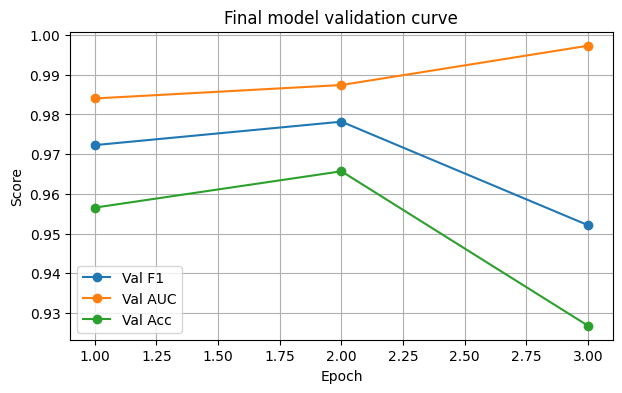

In [ ]:
# ==============================
# 11. FINAL PROPOSED MODEL
# ==============================

final_model = None
final_preds = None

if RUN_FINAL_MODEL:
    print("#" * 120)
    print("FINAL MODEL: backbone + CBAM + quality-aware training")
    print("#" * 120)

    final_backbone = best_params.get("backbone", BACKBONES["EfficientNetV2S"])
    final_lr = best_params.get("lr", 1e-4)
    final_wd = best_params.get("weight_decay", 1e-4)
    final_dropout = best_params.get("dropout", 0.3)
    final_bs = best_params.get("batch_size", BATCH_SIZE)

    sampler = make_weighted_sampler(train_df)
    final_train_loader = make_loader(train_df, final_bs, mode="train", sampler=sampler, img_size=IMG_SIZE, quality_training=True)
    final_val_loader = make_loader(val_df, final_bs, mode="eval", img_size=IMG_SIZE)
    final_test_loader = make_loader(test_df, final_bs, mode="eval", img_size=IMG_SIZE)

    final_model = create_model(final_backbone, pretrained=True, use_cbam=True, dropout=final_dropout)

    final_model, final_hist = fit_model(
        final_model,
        final_train_loader,
        final_val_loader,
        epochs=FINAL_EPOCHS,
        lr=final_lr,
        weight_decay=final_wd,
        multitask_quality=True,
        verbose=True,
        patience=8 if RUN_MODE == "PAPER" else 5
    )

    final_preds = predict_model(final_model, final_test_loader)
    main, q_summary, unsafe = evaluate_predictions(final_preds, title="FINAL TEST METRICS - DFU-ImageGuard Binary")

    row = main.copy()
    row["experiment"] = "FINAL_DFU_ImageGuard_Binary"
    row["backbone"] = final_backbone
    row["cbam"] = True
    row["quality_training"] = True
    experiment_results.append(row)

    print("FINAL COMPARISON TABLE:")
    comparison_df = pd.DataFrame(experiment_results).sort_values("auc", ascending=False).reset_index(drop=True)
    display(comparison_df.round(5))

    plt.figure(figsize=(7, 4))
    plt.plot(final_hist["epoch"], final_hist["val_f1"], marker="o", label="Val F1")
    plt.plot(final_hist["epoch"], final_hist["val_auc"], marker="o", label="Val AUC")
    plt.plot(final_hist["epoch"], final_hist["val_acc"], marker="o", label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Final model validation curve")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Skipping final model.")

In [ ]:
# ==============================
# 12. ABLATION STUDY
# ==============================

ablation_results = []

def run_ablation(name, backbone, use_cbam, quality_training, multitask_quality, epochs=None):
    if epochs is None:
        epochs = BASELINE_EPOCHS

    print("=" * 120)
    print("ABLATION:", name)
    print("=" * 120)

    bs = best_params.get("batch_size", BATCH_SIZE)
    sampler = make_weighted_sampler(train_df)

    tr_loader = make_loader(train_df, bs, mode="train", sampler=sampler, img_size=IMG_SIZE, quality_training=quality_training)
    va_loader = make_loader(val_df, bs, mode="eval", img_size=IMG_SIZE)
    te_loader = make_loader(test_df, bs, mode="eval", img_size=IMG_SIZE)

    model = create_model(backbone, pretrained=True, use_cbam=use_cbam, dropout=best_params.get("dropout", 0.3))

    model, hist = fit_model(
        model,
        tr_loader,
        va_loader,
        epochs=epochs,
        lr=best_params.get("lr", 1e-4),
        weight_decay=best_params.get("weight_decay", 1e-4),
        multitask_quality=multitask_quality,
        verbose=True,
        patience=5
    )

    preds = predict_model(model, te_loader)
    main, _, _ = evaluate_predictions(preds, title=f"ABLATION TEST - {name}")

    row = main.copy()
    row["ablation"] = name
    row["cbam"] = use_cbam
    row["quality_aug"] = quality_training
    row["quality_loss"] = multitask_quality
    ablation_results.append(row)

    del model
    torch.cuda.empty_cache()

if RUN_ABLATION:
    ab_backbone = best_params.get("backbone", BACKBONES["EfficientNetV2S"])
    run_ablation("A1_Raw_Backbone", ab_backbone, use_cbam=False, quality_training=False, multitask_quality=False)
    run_ablation("A2_Backbone_CBAM", ab_backbone, use_cbam=True, quality_training=False, multitask_quality=False)
    run_ablation("A3_CBAM_QualityAug_NoQualityLoss", ab_backbone, use_cbam=True, quality_training=True, multitask_quality=False)
    run_ablation("A4_CBAM_QualityAug_QualityLoss", ab_backbone, use_cbam=True, quality_training=True, multitask_quality=True)

    print("ABLATION SUMMARY:")
    display(pd.DataFrame(ablation_results).sort_values("auc", ascending=False).round(5))
else:
    print("Skipping ablation.")

ABLATION: A1_Raw_Backbone


train:   0%|          | 0/106 [00:00<?, ?it/s]

predict:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 001/2 | loss=0.1745 | val_acc=0.9657 | val_f1=0.9785 | val_auc=0.9933


train:   0%|          | 0/106 [00:00<?, ?it/s]

...

,task,accuracy,macro_precision,macro_recall,macro_f1,ece,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier
0,quality_3class,0.93818,0.5,0.46909,0.48405,0.39213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,unsafe_image_detection,0.98364,NaN,NaN,NaN,0.16290,0.98364,0.0,0.0,0.98364,1.0,0.0,NaN,0.0,0.0,NaN


DFU binary confusion matrix


,Pred_Normal,Pred_DFU
True_Normal,127,0
True_DFU,183,240


Classification report:
              precision    recall  f1-score   support

      Normal       0.41      1.00      0.58       127
         DFU       1.00      0.57      0.72       423

    accuracy                           0.67       550
   macro avg       0.70      0.78      0.65       550
weighted avg       0.86      0.67      0.69       550

ABLATION SUMMARY:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,ablation,cbam,quality_aug,quality_loss
0,DFU_detection,0.89818,0.93381,1.0,0.86761,1.0,0.69399,0.92911,0.99942,0.77596,0.75165,0.07536,0.04926,A1_Raw_Backbone,False,False,False
2,DFU_detection,0.92909,0.95390,1.0,0.90780,1.0,0.76506,0.95167,0.99892,0.83338,0.81973,0.05523,0.04671,A3_CBAM_QualityAug_NoQualityLoss,True,True,False
3,DFU_detection,0.66727,0.78369,1.0,0.56738,1.0,0.40968,0.72398,0.99207,0.48212,0.37720,0.24875,0.16749,A4_CBAM_QualityAug_QualityLoss,True,True,True
1,DFU_detection,0.90000,0.93499,1.0,0.86998,1.0,0.69780,0.93047,0.99201,0.77915,0.75550,0.08367,0.07251,A2_Backbone_CBAM,True,False,False


In [ ]:
# ==============================
# 13. 5-FOLD LEAKAGE-SAFE CROSS-VALIDATION
# ==============================

cv_results = []

def run_5fold_cv(frame, backbone=None, epochs=CV_EPOCHS):
    if backbone is None:
        backbone = best_params.get("backbone", BACKBONES["EfficientNetV2S"])

    y = frame["label"].values
    groups = frame["leakage_group"].values
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=2026)

    for fold, (tr_idx, va_idx) in enumerate(sgkf.split(frame, y, groups), start=1):
        print("#" * 120)
        print(f"5-FOLD CV | Fold {fold}/5")
        print("#" * 120)

        tr_df = frame.iloc[tr_idx].reset_index(drop=True)
        va_df = frame.iloc[va_idx].reset_index(drop=True)

        overlap = len(set(tr_df["leakage_group"]) & set(va_df["leakage_group"]))
        print("Group/hash overlap:", overlap)

        bs = best_params.get("batch_size", BATCH_SIZE)
        sampler = make_weighted_sampler(tr_df)
        tr_loader = make_loader(tr_df, bs, mode="train", sampler=sampler, img_size=IMG_SIZE, quality_training=True)
        va_loader = make_loader(va_df, bs, mode="eval", img_size=IMG_SIZE)

        model = create_model(backbone, pretrained=True, use_cbam=True, dropout=best_params.get("dropout", 0.3))

        model, hist = fit_model(
            model,
            tr_loader,
            va_loader,
            epochs=epochs,
            lr=best_params.get("lr", 1e-4),
            weight_decay=best_params.get("weight_decay", 1e-4),
            multitask_quality=True,
            verbose=True,
            patience=5
        )

        preds = predict_model(model, va_loader)
        metrics = compute_binary_metrics(preds["y"], preds["p"], name=f"fold_{fold}")
        metrics["fold"] = fold
        cv_results.append(metrics)

        print("Fold metrics:")
        display(pd.DataFrame([metrics]).round(5))

        del model
        torch.cuda.empty_cache()

    cv_df = pd.DataFrame(cv_results)
    print("5-FOLD CV SUMMARY:")
    display(cv_df.round(5))
    print("Mean ± Std:")
    display(cv_df.drop(columns=["task", "fold"], errors="ignore").agg(["mean", "std"]).T.round(5))
    return cv_df

if RUN_5FOLD_CV:
    cv_df = run_5fold_cv(df, epochs=CV_EPOCHS)
else:
    print("Skipping CV.")

########################################################################################################################
5-FOLD CV | Fold 1/5
########################################################################################################################
Group/hash overlap: 0


train:   0%|          | 0/133 [00:00<?, ?it/s]

predict:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 001/2 | loss=0.3715 | val_acc=0.7564 | val_f1=0.8118 | val_auc=0.9786


train:   0%|          | 0/133 [00:00<?, ?it/s]

...

,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,fold
0,fold_5,0.98336,0.97918,0.99302,0.98614,0.97222,0.94595,0.98957,0.99848,0.94862,0.94848,0.01314,0.01874,5


5-FOLD CV SUMMARY:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,fold
0,fold_1,0.98909,0.99291,1.00000,0.98582,1.00000,0.95489,0.99286,0.99974,0.97023,0.96979,0.00615,0.00750,1
1,fold_2,0.92161,0.94784,0.99741,0.90588,0.98980,0.70803,0.94945,0.99745,0.79489,0.77676,0.06584,0.08666,2
2,fold_3,0.90522,0.94302,1.00000,0.88605,1.00000,0.63971,0.93958,0.99770,0.75287,0.72352,0.08284,0.05460,3
3,fold_4,0.97963,0.98394,0.99755,0.97602,0.99187,0.92424,0.98667,0.99758,0.94456,0.94355,0.01408,0.01142,4
4,fold_5,0.98336,0.97918,0.99302,0.98614,0.97222,0.94595,0.98957,0.99848,0.94862,0.94848,0.01314,0.01874,5


Mean ± Std:


,mean,std
accuracy,0.95578,0.03925
balanced_accuracy,0.96938,0.02247
precision,0.99760,0.00285
recall_sensitivity,0.94798,0.04817
specificity,0.99078,0.01136
npv,0.83456,0.14909
f1,0.97162,0.02509
auc,0.99819,0.00095
mcc,0.88223,0.10050
cohen_kappa,0.87242,0.11363


In [ ]:
# ==============================
# 14. QUALITY-STRATIFIED EVALUATION
# ==============================

quality_stratified_results = []

if RUN_QUALITY_STRATIFIED and final_model is not None:
    for q_level, q_name in enumerate(QUALITY_NAMES):
        print("#" * 120)
        print("QUALITY-STRATIFIED TEST:", q_name)
        print("#" * 120)

        q_loader = make_loader(
            test_df,
            best_params.get("batch_size", BATCH_SIZE),
            mode="eval",
            img_size=IMG_SIZE,
            eval_quality_level=q_level,
            quality_training=False
        )

        q_preds = predict_model(final_model, q_loader)
        main, q_summary, unsafe = evaluate_predictions(q_preds, title=f"TEST ON {q_name}")

        row = main.copy()
        row["quality_level"] = q_level
        row["quality_name"] = q_name
        row["unsafe_recall"] = unsafe["recall_sensitivity"]
        quality_stratified_results.append(row)

    print("QUALITY-STRATIFIED SUMMARY:")
    display(pd.DataFrame(quality_stratified_results).round(5))
else:
    print("Skipping quality-stratified evaluation.")

########################################################################################################################
QUALITY-STRATIFIED TEST: Good
########################################################################################################################


predict:   0%|          | 0/35 [00:00<?, ?it/s]

TEST ON Good


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece
0,DFU_detection,0.93091,0.95508,1.0,0.91017,1.0,0.7697,0.95297,0.99778,0.83699,0.82391,0.05938,0.03691


Quality and unsafe-image metrics


...

,task,accuracy,macro_precision,macro_recall,macro_f1,ece,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier
0,quality_3class,0.67091,0.33333,0.22364,0.26768,0.14142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,unsafe_image_detection,0.60727,NaN,NaN,NaN,0.22802,0.60727,1.0,0.60727,0.0,0.0,0.75566,NaN,0.0,0.0,NaN


DFU binary confusion matrix


,Pred_Normal,Pred_DFU
True_Normal,125,2
True_DFU,91,332


Classification report:
              precision    recall  f1-score   support

      Normal       0.58      0.98      0.73       127
         DFU       0.99      0.78      0.88       423

    accuracy                           0.83       550
   macro avg       0.79      0.88      0.80       550
weighted avg       0.90      0.83      0.84       550

QUALITY-STRATIFIED SUMMARY:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,quality_level,quality_name,unsafe_recall
0,DFU_detection,0.93091,0.95508,1.00000,0.91017,1.00000,0.76970,0.95297,0.99778,0.83699,0.82391,0.05938,0.03691,0,Good,0.00000
1,DFU_detection,0.93818,0.95981,1.00000,0.91962,1.00000,0.78882,0.95813,0.99764,0.85171,0.84086,0.05354,0.02802,1,Mild_Degraded,0.00000
2,DFU_detection,0.83091,0.88456,0.99401,0.78487,0.98425,0.57870,0.87715,0.96406,0.66369,0.61767,0.13223,0.07827,2,Severe_Unsafe,0.60727


In [ ]:
# ==============================
# 15. TEMPERATURE SCALING CALIBRATION
# ==============================

class BinaryTemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temp = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        temp = torch.exp(self.log_temp).clamp(0.05, 10.0)
        return logits / temp

@torch.no_grad()
def collect_binary_logits_labels(model, loader):
    model.eval()
    logits, labels = [], []
    for batch in tqdm(loader, leave=False, desc="collect logits"):
        batch = batch_to_device(batch)
        out = model(batch["image"])
        logits.append(out["dfu_logit"].detach().cpu())
        labels.append(batch["label"].detach().cpu())
    return torch.cat(logits), torch.cat(labels)

def fit_binary_temperature(logits, labels, max_iter=100):
    scaler = BinaryTemperatureScaler()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.LBFGS(scaler.parameters(), lr=0.1, max_iter=max_iter)

    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(logits), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler

if RUN_CALIBRATION and final_model is not None:
    val_logits, val_labels = collect_binary_logits_labels(final_model, final_val_loader)
    test_logits, test_labels = collect_binary_logits_labels(final_model, final_test_loader)

    before_probs = torch.sigmoid(test_logits).numpy()

    temp_scaler = fit_binary_temperature(val_logits, val_labels)
    after_probs = torch.sigmoid(temp_scaler(test_logits)).detach().numpy()

    before = compute_binary_metrics(test_labels.numpy().astype(int), before_probs, name="before_temperature_scaling")
    after = compute_binary_metrics(test_labels.numpy().astype(int), after_probs, name="after_temperature_scaling")

    print("Learned temperature:", float(torch.exp(temp_scaler.log_temp).detach().cpu()))
    display(pd.DataFrame([before, after]).round(5))
else:
    print("Skipping calibration.")

collect logits:   0%|          | 0/28 [00:00<?, ?it/s]

collect logits:   0%|          | 0/35 [00:00<?, ?it/s]

Learned temperature: 1.2210792303085327


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece
0,before_temperature_scaling,0.93091,0.95508,1.0,0.91017,1.0,0.7697,0.95297,0.99778,0.83699,0.82391,0.05938,0.03691
1,after_temperature_scaling,0.93091,0.95508,1.0,0.91017,1.0,0.7697,0.95297,0.99778,0.83699,0.82391,0.05932,0.02683


In [ ]:
# ==============================
# 16. UNCERTAINTY ABSTENTION + DECISION LOGIC
# ==============================

def decision_logic(preds, confidence_threshold=0.70, unsafe_threshold=0.50, dfu_threshold=0.50):
    prob_dfu = preds["p"]
    pred = (prob_dfu >= dfu_threshold).astype(int)
    conf = np.maximum(prob_dfu, 1 - prob_dfu)
    unsafe_prob = preds["pq"][:, 2]

    decisions = []
    for i in range(len(prob_dfu)):
        if unsafe_prob[i] >= unsafe_threshold:
            decisions.append("Retake image: unsafe image quality")
        elif conf[i] < confidence_threshold:
            decisions.append("Clinician review: uncertain prediction")
        elif prob_dfu[i] >= dfu_threshold:
            decisions.append("Refer for clinical assessment")
        else:
            decisions.append("Routine monitoring")

    return np.array(decisions), conf, pred, unsafe_prob

def abstention_summary(preds, confidence_thresholds=[0.50, 0.60, 0.70, 0.80, 0.90]):
    rows = []
    y_true = preds["y"]
    prob = preds["p"]
    pred = (prob >= 0.5).astype(int)
    conf = np.maximum(prob, 1 - prob)

    for th in confidence_thresholds:
        accept = conf >= th
        coverage = accept.mean()

        if accept.sum() > 0:
            accepted_acc = accuracy_score(y_true[accept], pred[accept])
            accepted_f1 = precision_recall_fscore_support(y_true[accept], pred[accept], average="binary", zero_division=0)[2]
        else:
            accepted_acc = np.nan
            accepted_f1 = np.nan

        rejected_error_rate = np.mean(y_true[~accept] != pred[~accept]) if (~accept).sum() > 0 else np.nan

        rows.append({
            "confidence_threshold": th,
            "coverage_accepted_fraction": coverage,
            "accepted_accuracy": accepted_acc,
            "accepted_f1": accepted_f1,
            "rejected_error_rate": rejected_error_rate,
            "n_accepted": int(accept.sum()),
            "n_rejected": int((~accept).sum())
        })

    return pd.DataFrame(rows)

if final_preds is not None:
    print("ABSTENTION SUMMARY:")
    display(abstention_summary(final_preds).round(5))

    decisions, conf, cls_pred, unsafe_prob = decision_logic(final_preds)

    decision_df = pd.DataFrame({
        "path": final_preds["paths"],
        "true_class": [CLASS_NAMES[i] for i in final_preds["y"]],
        "pred_class": [CLASS_NAMES[i] for i in cls_pred],
        "dfu_probability": final_preds["p"],
        "confidence": conf,
        "unsafe_quality_prob": unsafe_prob,
        "decision": decisions
    })

    print("Decision distribution:")
    display(decision_df["decision"].value_counts().to_frame("count"))

    print("Sample decisions:")
    display(decision_df.head(20).round(4))
else:
    print("Final predictions not available.")

ABSTENTION SUMMARY:


,confidence_threshold,coverage_accepted_fraction,accepted_accuracy,accepted_f1,rejected_error_rate,n_accepted,n_rejected
0,0.5,1.00000,0.93091,0.95297,NaN,550,0
1,0.6,0.98000,0.93506,0.95564,0.27273,539,11
2,0.7,0.95455,0.94667,0.96354,0.40000,525,25
3,0.8,0.90545,0.94779,0.96369,0.23077,498,52
4,0.9,0.85636,0.95966,0.97160,0.24051,471,79


Decision distribution:


,count
decision,
Refer for clinical assessment,370
Routine monitoring,155
Clinician review: uncertain prediction,25


Sample decisions:


,path,true_class,pred_class,dfu_probability,confidence,unsafe_quality_prob,decision
0,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/i...,DFU,DFU,0.9932,0.9932,0.0566,Refer for clinical assessment
1,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/d...,DFU,DFU,0.9679,0.9679,0.0715,Refer for clinical assessment
2,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/8...,DFU,DFU,0.9741,0.9741,0.0344,Refer for clinical assessment
3,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/C...,DFU,Normal,0.0184,0.9816,0.0342,Routine monitoring
4,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/c...,DFU,DFU,0.9629,0.9629,0.0470,Refer for clinical assessment
5,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/d...,DFU,DFU,0.9737,0.9737,0.0775,Refer for clinical assessment
6,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/f...,DFU,DFU,0.7469,0.7469,0.1209,Refer for clinical assessment
7,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/i...,DFU,DFU,0.8297,0.8297,0.0545,Refer for clinical assessment
8,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/i...,DFU,DFU,0.9929,0.9929,0.1430,Refer for clinical assessment
9,/content/diabetic-foot-ulcer-dfu/DFU/TestSet/B...,DFU,DFU,0.9816,0.9816,0.0569,Refer for clinical assessment


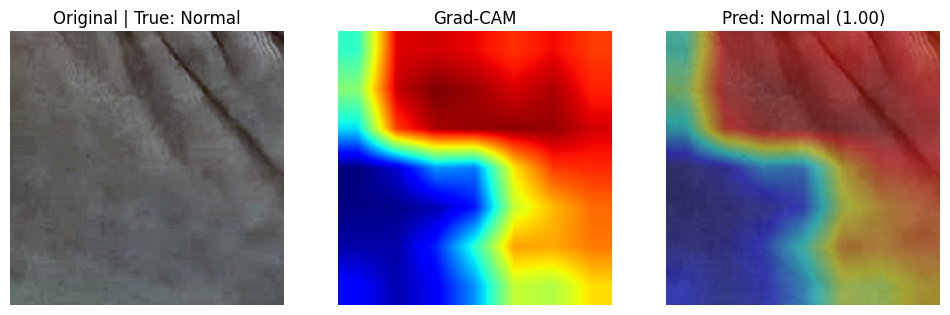

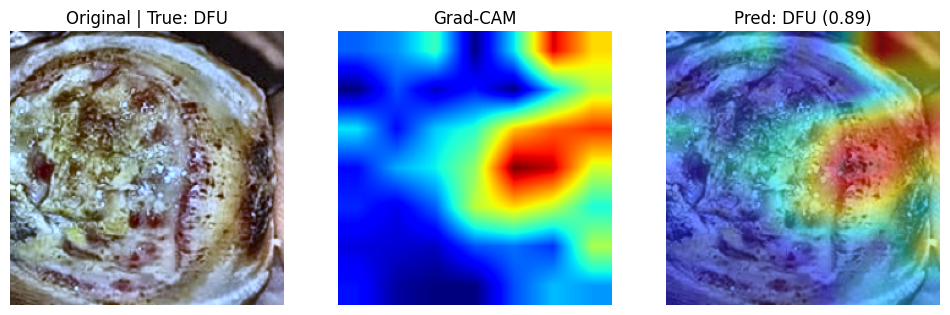

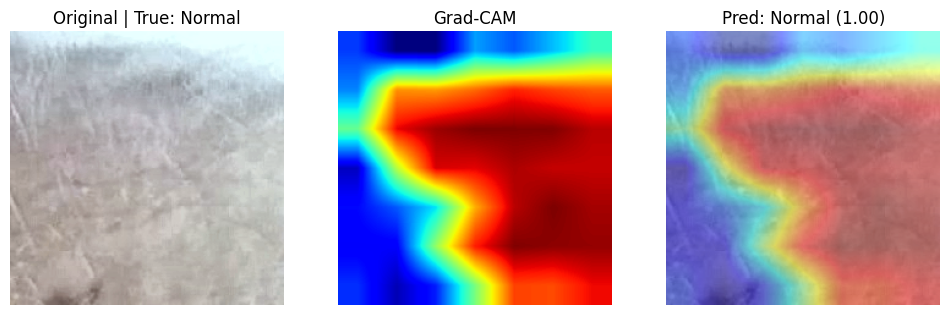

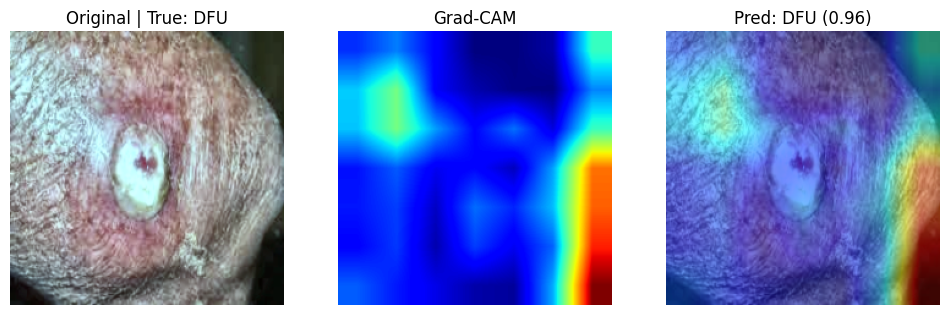

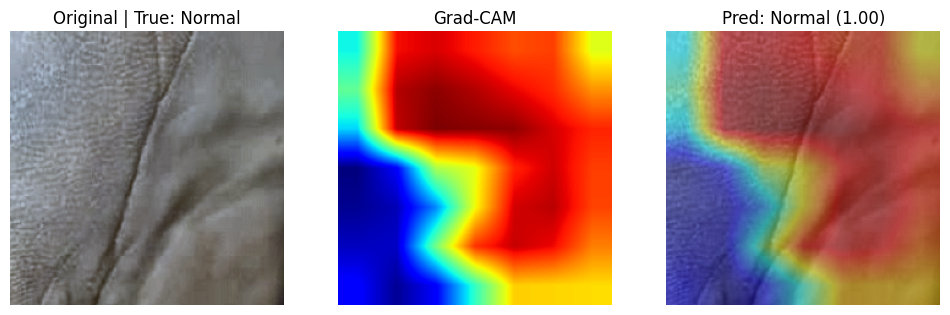

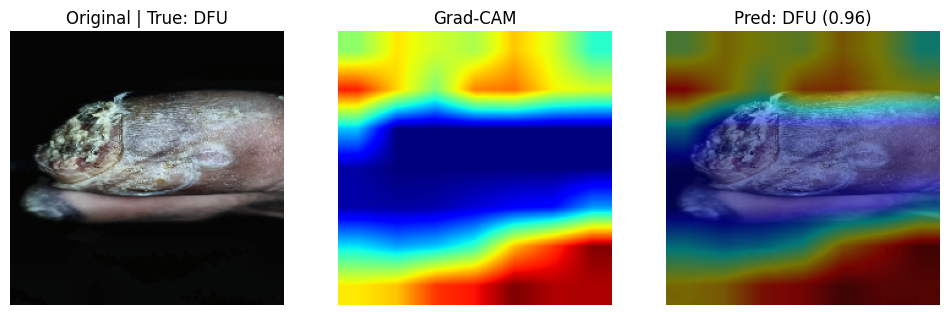

In [ ]:
# ==============================
# 17. GRAD-CAM XAI
# ==============================

def denormalize_tensor_img(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = x.detach().cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

def make_gradcam(model, image_tensor, target_positive=True):
    model.eval()
    model.zero_grad(set_to_none=True)

    x = image_tensor.unsqueeze(0).to(DEVICE)
    out = model(x)
    logit = out["dfu_logit"][0]

    score = logit if target_positive else -logit
    score.backward()

    feat = model.last_feature_map.detach()
    grad = model.last_feature_map.grad.detach()

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * feat).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=image_tensor.shape[-2:], mode="bilinear", align_corners=False)

    cam = cam[0, 0].detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

def show_gradcam_examples(model, dataset, n=6):
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)

    for idx in idxs:
        sample = dataset[idx]
        img_t = sample["image"]

        with torch.no_grad():
            out = model(img_t.unsqueeze(0).to(DEVICE))
            prob = float(torch.sigmoid(out["dfu_logit"])[0].detach().cpu())
            pred = int(prob >= 0.5)
            conf = max(prob, 1 - prob)

        cam = make_gradcam(model, img_t, target_positive=(pred == 1))
        img = denormalize_tensor_img(img_t)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.55 * img + 0.45 * heatmap, 0, 1)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Original | True: {CLASS_NAMES[int(sample['label'])]}")

        plt.subplot(1, 3, 2)
        plt.imshow(cam, cmap="jet")
        plt.axis("off")
        plt.title("Grad-CAM")

        plt.subplot(1, 3, 3)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(f"Pred: {CLASS_NAMES[pred]} ({conf:.2f})")

        plt.show()

if RUN_XAI_GRADCAM and final_model is not None:
    xai_ds = DFUBinaryDataset(test_df, img_size=IMG_SIZE, mode="eval", eval_quality_level=0)
    show_gradcam_examples(final_model, xai_ds, n=6)
else:
    print("Skipping Grad-CAM.")

  0%|          | 0/500 [00:00<?, ?it/s]

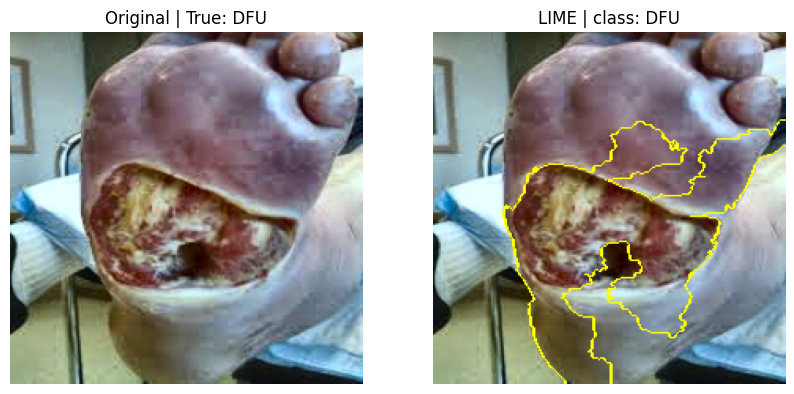

In [ ]:
# ==============================
# 18. LIME XAI
# ==============================

if RUN_XAI_LIME and final_model is not None:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries

    final_model.eval()
    lime_ds = DFUBinaryDataset(test_df, img_size=IMG_SIZE, mode="eval", eval_quality_level=0)

    def preprocess_lime_images(images_np):
        batch_tensors = []
        eval_tf = get_eval_transform(IMG_SIZE)

        for img in images_np:
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

            transformed = eval_tf(image=img)["image"]
            batch_tensors.append(transformed)

        return torch.stack(batch_tensors)

    def lime_predict(images_np):
        x = preprocess_lime_images(images_np).to(DEVICE)
        with torch.no_grad():
            out = final_model(x)
            prob_dfu = torch.sigmoid(out["dfu_logit"]).detach().cpu().numpy()
        probs = np.column_stack([1 - prob_dfu, prob_dfu])
        return probs

    sample = lime_ds[0]
    img = denormalize_tensor_img(sample["image"])
    img_uint8 = (img * 255).astype(np.uint8)

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_uint8,
        lime_predict,
        top_labels=2,
        hide_color=0,
        num_samples=500 if RUN_MODE == "QUICK" else 1500
    )

    top_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=8,
        hide_rest=False
    )

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Original | True: {CLASS_NAMES[int(sample['label'])]}")

    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp / 255.0 if temp.max() > 1 else temp, mask))
    plt.axis("off")
    plt.title(f"LIME | class: {CLASS_NAMES[top_label]}")

    plt.show()
else:
    print("Skipping LIME.")

In [ ]:
# ==============================
# 19. OPTIONAL SHAP XAI
# ==============================

if RUN_XAI_SHAP and final_model is not None:
    import shap

    class TwoClassWrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            out = self.model(x)
            logit = out["dfu_logit"]
            return torch.stack([-logit, logit], dim=1)

    wrapper = TwoClassWrapper(final_model).to(DEVICE).eval()

    bg_batch = next(iter(final_train_loader))["image"][:4].to(DEVICE)
    test_batch = next(iter(final_test_loader))["image"][:2].to(DEVICE)

    explainer = shap.GradientExplainer(wrapper, bg_batch)
    shap_values = explainer.shap_values(test_batch)

    test_imgs = test_batch.detach().cpu()
    test_imgs_np = np.stack([denormalize_tensor_img(x) for x in test_imgs], axis=0)

    print("SHAP values computed.")
    try:
        shap.image_plot(shap_values, test_imgs_np)
    except Exception as e:
        print("SHAP plotting failed, but SHAP values were computed.")
        print("Error:", repr(e))
else:
    print("Skipping SHAP. Set RUN_XAI_SHAP=True for final paper run.")

Skipping SHAP. Set RUN_XAI_SHAP=True for final paper run.


In [ ]:
# ==============================
# 20. FINAL PAPER-READY SUMMARY TABLES
# ==============================

print("MAIN EXPERIMENT COMPARISON:")
if len(experiment_results) > 0:
    display(pd.DataFrame(experiment_results).sort_values("auc", ascending=False).round(5))
else:
    print("No experiment results yet.")

print("ABLATION SUMMARY:")
if len(ablation_results) > 0:
    display(pd.DataFrame(ablation_results).sort_values("auc", ascending=False).round(5))
else:
    print("No ablation results yet.")

print("QUALITY-STRATIFIED SUMMARY:")
if len(quality_stratified_results) > 0:
    display(pd.DataFrame(quality_stratified_results).round(5))
else:
    print("No quality-stratified results yet.")

print("CV SUMMARY:")
if len(cv_results) > 0:
    cv_df = pd.DataFrame(cv_results)
    display(cv_df.round(5))
    display(cv_df.drop(columns=["task", "fold"], errors="ignore").agg(["mean", "std"]).T.round(5))
else:
    print("No CV results yet.")

print("Suggested novelty statement:")
print("DFU-ImageGuard is a quality-aware explainable telemedicine screening framework rather than a simple binary classifier.")
print("It detects DFU, predicts image reliability, rejects unsafe patient-submitted images, applies uncertainty abstention, gives retake/referral decisions, and explains predictions using XAI.")

MAIN EXPERIMENT COMPARISON:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,experiment,backbone,cbam,quality_training
3,DFU_detection,0.99455,0.99645,1.00000,0.99291,1.00000,0.97692,0.99644,0.99978,0.98488,0.98477,0.00441,0.00309,Baseline_ConvNeXtTiny,convnext_tiny,False,False
2,DFU_detection,0.98182,0.98818,1.00000,0.97636,1.00000,0.92701,0.98804,0.99972,0.95136,0.95018,0.01726,0.01680,Baseline_EfficientNetV2S,tf_efficientnetv2_s.in21k,False,False
4,DFU_detection,0.98909,0.99015,0.99761,0.98818,0.99213,0.96183,0.99287,0.99961,0.96982,0.96962,0.00888,0.01025,Baseline_SwinTiny,swin_tiny_patch4_window7_224,False,False
1,DFU_detection,0.96909,0.97715,0.99755,0.96217,0.99213,0.88732,0.97954,0.99944,0.91893,0.91643,0.02180,0.01737,Baseline_EfficientNetB0,efficientnet_b0,False,False
5,DFU_detection,0.93091,0.95508,1.00000,0.91017,1.00000,0.76970,0.95297,0.99778,0.83699,0.82391,0.05938,0.03691,FINAL_DFU_ImageGuard_Binary,convnext_tiny,True,True
0,DFU_detection,0.80000,0.86998,1.00000,0.73995,1.00000,0.53586,0.85054,0.99563,0.62969,0.56786,0.20639,0.24322,Baseline_ResNet50,resnet50,False,False


ABLATION SUMMARY:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,ablation,cbam,quality_aug,quality_loss
0,DFU_detection,0.89818,0.93381,1.0,0.86761,1.0,0.69399,0.92911,0.99942,0.77596,0.75165,0.07536,0.04926,A1_Raw_Backbone,False,False,False
2,DFU_detection,0.92909,0.95390,1.0,0.90780,1.0,0.76506,0.95167,0.99892,0.83338,0.81973,0.05523,0.04671,A3_CBAM_QualityAug_NoQualityLoss,True,True,False
3,DFU_detection,0.66727,0.78369,1.0,0.56738,1.0,0.40968,0.72398,0.99207,0.48212,0.37720,0.24875,0.16749,A4_CBAM_QualityAug_QualityLoss,True,True,True
1,DFU_detection,0.90000,0.93499,1.0,0.86998,1.0,0.69780,0.93047,0.99201,0.77915,0.75550,0.08367,0.07251,A2_Backbone_CBAM,True,False,False


QUALITY-STRATIFIED SUMMARY:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,quality_level,quality_name,unsafe_recall
0,DFU_detection,0.93091,0.95508,1.00000,0.91017,1.00000,0.76970,0.95297,0.99778,0.83699,0.82391,0.05938,0.03691,0,Good,0.00000
1,DFU_detection,0.93818,0.95981,1.00000,0.91962,1.00000,0.78882,0.95813,0.99764,0.85171,0.84086,0.05354,0.02802,1,Mild_Degraded,0.00000
2,DFU_detection,0.83091,0.88456,0.99401,0.78487,0.98425,0.57870,0.87715,0.96406,0.66369,0.61767,0.13223,0.07827,2,Severe_Unsafe,0.60727


CV SUMMARY:


,task,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,auc,mcc,cohen_kappa,brier,ece,fold
0,fold_1,0.98909,0.99291,1.00000,0.98582,1.00000,0.95489,0.99286,0.99974,0.97023,0.96979,0.00615,0.00750,1
1,fold_2,0.92161,0.94784,0.99741,0.90588,0.98980,0.70803,0.94945,0.99745,0.79489,0.77676,0.06584,0.08666,2
2,fold_3,0.90522,0.94302,1.00000,0.88605,1.00000,0.63971,0.93958,0.99770,0.75287,0.72352,0.08284,0.05460,3
3,fold_4,0.97963,0.98394,0.99755,0.97602,0.99187,0.92424,0.98667,0.99758,0.94456,0.94355,0.01408,0.01142,4
4,fold_5,0.98336,0.97918,0.99302,0.98614,0.97222,0.94595,0.98957,0.99848,0.94862,0.94848,0.01314,0.01874,5


,mean,std
accuracy,0.95578,0.03925
balanced_accuracy,0.96938,0.02247
precision,0.99760,0.00285
recall_sensitivity,0.94798,0.04817
specificity,0.99078,0.01136
npv,0.83456,0.14909
f1,0.97162,0.02509
auc,0.99819,0.00095
mcc,0.88223,0.10050
cohen_kappa,0.87242,0.11363


Suggested novelty statement:
DFU-ImageGuard is a quality-aware explainable telemedicine screening framework rather than a simple binary classifier.
It detects DFU, predicts image reliability, rejects unsafe patient-submitted images, applies uncertainty abstention, gives retake/referral decisions, and explains predictions using XAI.
